In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print("데이터기본정보")
print(f"학습데이터(X_train) 형태: ", X_train.shape)
print(f"레이블(y_train) 형태: ", y_train.shape) 
print(f"픽셀값범위: ", X_train.min(), " ~ ", X_train.max())

데이터기본정보
학습데이터(X_train) 형태:  (60000, 28, 28)
레이블(y_train) 형태:  (60000,)
픽셀값범위:  0  ~  255


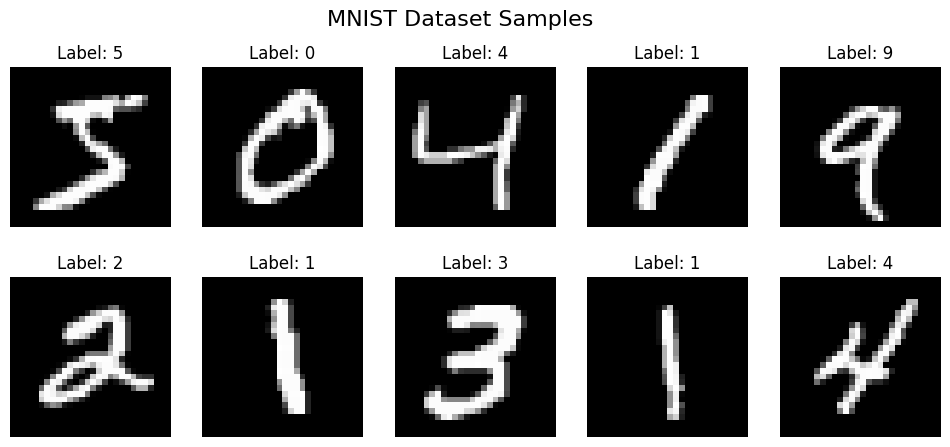

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+ 1) 
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle('MNIST Dataset Samples', fontsize=16)
plt.show()

In [ ]:
X_train_flat= X_train.reshape(-1, 28 * 28) / 255.0
np.random.seed(42)
indices = np.random.permutation(len(X_train_flat))[:3000]
X_subset= X_train_flat[indices]
y_subset= y_train[indices]

print(f"실습데이터형태(Shape): {X_subset.shape}")

실습데이터형태(Shape): (3000, 784)


In [ ]:
pca= PCA(n_components=2)
X_pca= pca.fit_transform(X_subset)
print(f"PCA변환후데이터형태: {X_pca.shape}")

PCA변환후데이터형태: (3000, 2)


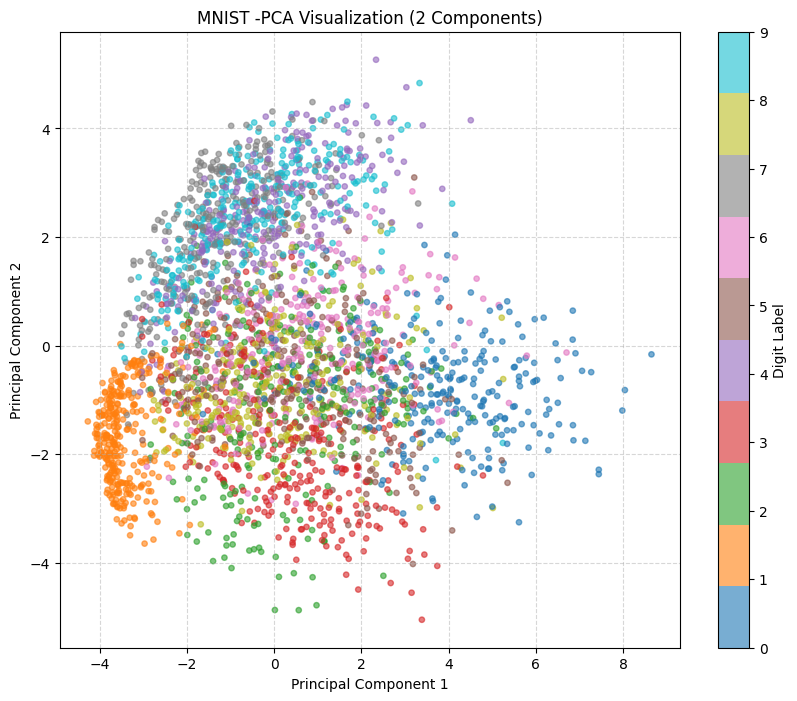

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_subset, cmap='tab10',alpha=0.6, s=15)
plt.colorbar(scatter, label='Digit Label')
plt.title('MNIST -PCA Visualization (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print("t-SNE 변환을시작합니다.")

print("2차원t-SNE 학습중...")
tsne_2d = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne_2d = tsne_2d.fit_transform(X_subset)

print("3차원t-SNE 학습중...")
tsne_3d = TSNE(n_components=3, random_state=42, init='pca', learning_rate='auto')
X_tsne_3d = tsne_3d.fit_transform(X_subset)

t-SNE 변환을시작합니다.
2차원t-SNE 학습중...
3차원t-SNE 학습중...


In [ ]:
fig = plt.figure(figsize=(13, 10))
scatter = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c = y_subset, cmap='tab10', alpha=0.6, s=25)
plt.title('t-SNE Visualization (2D)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.colorbar(scatter, label='Digit Label')
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1,1,1, projection='3d')

scatter2 = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c = y_subset, s=9, cmap='tab10', alpha=0.6)
ax.set_title('t-SNE Visualization (3D)', fontsize=14)
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_zlabel('Dim 3')
plt.colorbar(scatter2, label='Digit Label')

ax.view_init(elev=20, azim=45)
plt.show()

In [ ]:
plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_subset, cmap='tab10', alpha=0.6, s=10)
plt.title('PCA: Linear Projection', fontsize=15, fontweight='bold')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_subset, cmap='tab10', alpha=0.6, s=10)
plt.title('t-SNE: Manifold Embedding', fontsize=15, fontweight='bold')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.colorbar(label='Digit')
plt.grid(True, alpha=0.3)

plt.suptitle('Comparison: PCA vs. t-SNE on MNIST', fontsize=20)
plt.show()

In [ ]:
data_with_labels= np.hstack((X_subset, y_subset.reshape(-1, 1)))
print("Concatenated shape:", data_with_labels.shape)  # (3000, 785)
np.savetxt('Mnist3000.csv', data_with_labels, fmt='%d', delimiter=',')